<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png" width=auto height=200px align=left>
</div>

# KUL H02A5a Computer Vision — Group Assignment 1

**Team 27** | Fosteris Emmanouil · Paschalidis Marios · Greiner Luc · Reyes Salazar Jose · Digenis Stefanos

---

### Notebook structure

| Section | Content |
|---------|---------|
| 0 | Data loading & preprocessing |
| 1 | Feature representations (HOG, PCA) |
| 2 | Evaluation metrics |
| 3 | Classifiers |
| 4 | Experiments |
| 5 | Best results & submission |
| 6 | Discussion |

> **Helper modules** (imported below):
> - `face_detection.py` — HAARPreprocessor, DNNFaceDetector
> - `preprocessing.py`  — face_to_gray, HOG/PCA helpers, train/val split
> - `visualize.py`       — all plotting functions
> - `annotate.py`       — all data annotations functions


## Imports

In [1]:
import os, math, shutil, threading
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from skimage.feature import hog

# Local modules
from face_detection  import DNNFaceDetector, HAARPreprocessor, run_preprocessing
from preprocessing   import (face_to_gray, convert_crops_to_gray, extract_hog_batch,
                              flatten_images, normalize_per_image, apply_pca,
                              get_train_val_split, summarize_dataset, save_crops)
from visualize       import (plot_class_distribution, plot_class_grid, plot_face_debug,
                              plot_image_sequence, plot_hog_features, plot_tsne,
                              plot_eigenfaces, plot_explained_variance,
                              plot_pca_reconstruction, plot_pca_scatter,
                              plot_validation_images, plot_confusion_matrix)
from annotate import FaceAnnotator, load_data, run_multi_annotation
import json
import random


---
# 0. Data Loading & Preprocessing


In [ ]:
# Global constants used throughout the notebook
DATASET_FOLDER = "datasets/train/"  # Where the original .npy files are
ANNOTATIONS_CSV = "annotations.csv"
FACE_SIZE   = (150, 150)
TARGET_SIZE = (64, 64)     # HOG/PCA input size
CLASS_NAMES = {
    0: "Michael_Cera",
    1: "Jesse_Eisenberg",
    2: "Mila_Kunis",
    3: "Sarah_Hyland",
    4: "Not_A_Face"
}

## 0.1 Load data

The training set is intentionally small (80 images) relative to the test set (1816 images).
This mirrors a real-world scenario: a model trained on a handful of labelled examples must
generalise to daily production traffic.

The dataset is a subset of the [VGG Face Dataset](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/)
and contains four people:

| Person | Class label | # images |
|--------|-------------|----------|
| Jesse Eisenberg | 1 | 30 |
| Mila Kunis | 2 | 30 |
| Michael Cera (Jesse lookalike) | 0 | 10 |
| Sarah Hyland (Mila lookalike) | 0 | 10 |

Michael and Sarah are intentionally included to test whether the classifier can distinguish
the target person from someone who looks similar.


In [2]:
train = pd.read_csv('datasets/train_set.csv', index_col=0)
train.index = train.index.rename('id')

test = pd.read_csv('datasets/test_set.csv', index_col=0)
test.index = test.index.rename('id')

# Load raw images as RGB numpy arrays
train['img'] = [cv2.cvtColor(np.load(f'datasets/train/train_{i}.npy', allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in train.iterrows()]
test['img']  = [cv2.cvtColor(np.load(f'datasets/test/test_{i}.npy',  allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in test.iterrows()]

print(f"Training set : {len(train)} images")
print(f"Test set     : {len(test)}  images")

Training set : 80 images
Test set     : 1816  images


## 0.2 Exploratory analysis

Before preprocessing, we inspect the class distribution and basic image statistics.
This confirms the class imbalance (Jesse/Mila have 3× more images than the lookalikes)
and checks whether images have consistent dimensions.


                 img  class
name                       
Jesse_Eisenberg   30      1
Michael_Cera      10      0
Mila_Kunis        30      2
Sarah_Hyland      10      0


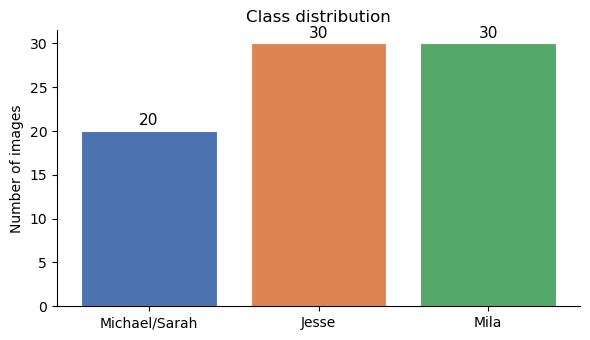

In [3]:
# Class distribution
print(train.groupby('name').agg({'img': 'count', 'class': 'max'}))
plot_class_distribution(train['class'].values, class_names={0:'Michael/Sarah',1:'Jesse',2:'Mila'})

In [4]:
# Image size statistics — check for dimension variation before choosing FACE_SIZE
train['h'] = train['img'].apply(lambda x: x.shape[0])
train['w'] = train['img'].apply(lambda x: x.shape[1])
train['aspect'] = train['w'] / train['h']
train[['h', 'w', 'aspect']].describe().round(2)

,h,w,aspect
count,80.00,80.00,80.00
mean,494.22,420.74,0.93
std,276.21,189.10,0.38
min,168.00,198.00,0.57
25%,360.00,300.00,0.67
50%,447.00,393.50,0.74
75%,594.00,480.00,1.06
max,2304.00,1536.00,2.08


## 0.3 Face detection & preprocessing

Raw images contain backgrounds, clothing, and sometimes multiple people.
We must isolate just the face region before extracting features — otherwise HOG and PCA
will describe the scene rather than the person.

### Approach: HAAR vs DNN

We evaluated two OpenCV face detectors:

| Detector | Mechanism | False positives | Group shots |
|----------|-----------|-----------------|-------------|
| **HAAR** cascade | Hand-crafted edge filters | Many (shirts, walls) — required 7 post-filters | Struggles — no confidence score |
| **DNN** ResNet-SSD | Learned CNN features | Almost none — model rejects non-faces internally | Better — confidence score breaks ties |

**We use DNN for all experiments.** HAAR is kept for comparison in section 4.

Both detectors feed into the same scoring function:

```
score = confidence² × face_area × centre_weight × sharpness
```

- `confidence²`: DNN certainty, squared to make high-confidence detections dominate
- `face_area`: fraction of image covered — rewards prominent subjects
- `centre_weight`: Gaussian decay from rule-of-thirds target (35% from top) — portrait framing bias
- `sharpness`: Laplacian variance of the crop — foreground subjects are always sharper than background faces


In [ ]:

# Run both detectors — results are cached so subsequent runs load from disk
train_X_dnn,  train_y_dnn,  test_X  = run_preprocessing(
    train, test, detector='dnn',  face_size=FACE_SIZE,
    model_path='tmp', cache_path='dnn_prepped_data'
)

train_X_haar, train_y_haar, test_X_haar = run_preprocessing(
    train, test, detector='haar', face_size=FACE_SIZE,
    model_path='tmp', cache_path='haar_prepped_data'
)

Loading cached arrays from 'dnn_prepped_data' ...
  train_X: (80, 100, 100, 3)  train_y: (80,)  test_X: (1816, 100, 100, 3)
Loading cached arrays from 'haar_prepped_data' ...
  train_X: (80, 100, 100, 3)  train_y: (80,)  test_X: (1816, 100, 100, 3)


## 0.4 Verify extracted faces

We visually inspect the extracted crops for each class to confirm the detector is
selecting the correct person.  The debug plot shows the original image alongside its
extracted face crop so mis-detections are immediately obvious.

**Known limitations (documented here for the TAs):**

- ~4 Jesse images contain Michael Cera at similar size and position — both detectors
  pick the wrong person because the other face scores higher on area + sharpness.
  These 4 samples (~5% of Jesse's training data) are accepted as label noise;
  classifiers trained on real-world data routinely handle this level of noise.
- One Mila image (HP billboard) returns no face — the center-crop fallback is used.


In [ ]:
label_to_int = {v: k for k, v in CLASS_NAMES.items()}

# --- 2. Load the Data ---
df = pd.read_csv(ANNOTATIONS_CSV)

original_images = []
extracted_faces = []
labels = []

for _, row in df.iterrows():
    orig_file = row['original_file']     
    crop_path = row['saved_crop_path']
    label_str = row['manual_label']

    orig_path = os.path.join(DATASET_FOLDER, orig_file)

    # Only load if both the original file and your new crop exist
    if os.path.exists(orig_path) and pd.notna(crop_path) and os.path.exists(crop_path):
        
        # Load Original Image (.npy is BGR, convert to RGB)
        img_bgr = np.load(orig_path, allow_pickle=False)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        original_images.append(img_rgb)

        # Load Extracted Crop (.jpg is BGR, convert to RGB)
        crop_bgr = cv2.imread(crop_path)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        extracted_faces.append(crop_rgb)

        # Convert label back to integer (e.g., "Mila_Kunis" -> 2)
        labels.append(label_to_int[label_str])

# --- 3. Format Variables for visualize.py ---
# plot_face_debug expects a DataFrame with an 'img' column for the originals
train = pd.DataFrame({'img': original_images})
X_train_final = np.array(extracted_faces)
y_train_final = np.array(labels)

print(f"Successfully loaded {len(X_train_final)} annotated samples.")

np.save("final_train_extracted_faces/train_X.npy", X_train_final)
np.save("final_train_extracted_faces/train_y.npy", y_train_final)

# # --- 4. Your Plotting Loop ---
# for class_id in [3, 4]:  # Add 3 or 4 to this list if you want to see them too!
#     n = int((y_train_final == class_id).sum())
    
#     # Small safety check to prevent crashing if you didn't label any faces for a specific class yet
#     if n > 0:
#         print(f"\nPlotting {n} samples for class {class_id} ({CLASS_NAMES[class_id]})...")
#         plot_face_debug(train, X_train_final, y_train_final,
#                         class_id=class_id, n=n, class_names=CLASS_NAMES)

Successfully loaded 102 annotated samples.


In [8]:
# Quick dataset summary — confirms shapes and flags any remaining NaN crops
summarize_dataset(X_train_final, y_train_final, class_names=CLASS_NAMES)

Dataset summary:
  Total samples : 102
  Image shape   : (150, 150, 3)
  dtype         : uint8
  NaN crops     : 0
  Class counts  :
    0 — Michael_Cera: 12
    1 — Jesse_Eisenberg: 30
    2 — Mila_Kunis: 32
    3 — Sarah_Hyland: 11
    4 — Not_A_Face: 17


In [25]:
# train_X_dnn_original = train_X_dnn.copy()

# annotator = FaceAnnotator(
#     train_df         = train,
#     face_array       = train_X_dnn.copy(),
#     label_array      = train_y_dnn.copy(),
#     annotations_path = "manual_annotations.json"
# )

# train_X_final, train_y_final = annotator.build_final_dataset(
#     train_df    = train,
#     face_size   = FACE_SIZE,
#     output_dir  = "final_train_extracted_faces",
# )
# np.save(os.path.join('final_train_extracted_faces', "test_X.npy"), test_X)

In [ ]:
# annotator.plot_annotation_summary(
#     train_df             = train,
#     train_X_dnn_original = train_X_dnn_original,
#     train_X_final        = train_X_final,
#     train_y_final        = train_y_final,
# )

In [ ]:
# X = np.load("final_train_extracted_faces/train_X.npy")
# y = np.load("final_train_extracted_faces/train_y.npy")

# for i in range(len(y)):
#     print(i, y[i])
#     plt.imshow(X[i].astype("uint8"))
#     plt.title(f"label={y[i]}")
#     plt.show()

In [7]:
X_train_final = np.load(os.path.join('final_train_extracted_faces', "train_X.npy"))
y_train_final = np.load(os.path.join('final_train_extracted_faces', "train_y.npy"))
test_X  = np.load(os.path.join('final_train_extracted_faces', "test_X.npy"))

In [32]:
def augment(images, labels, num_variants=2):
    """
    Creates exactly (1 + num_variants) images per original image.
    Uses randomized combinations of mirroring, lighting, and geometric shifts
    so the dataset doesn't explode in size.
    """
    aug_X, aug_y = [], []
    h, w = images[0].shape[:2]
    center = (w // 2, h // 2)

    # Setup CLAHE
    clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for img, label in zip(images, labels):
        # 1. Always keep the clean original
        aug_X.append(img)
        aug_y.append(label)

        # 2. Generate exactly 'num_variants' additional augmented copies
        for _ in range(num_variants):
            aug_img = img.copy()

            # --- A. Random Mirror (50% chance) ---
            if random.choice([True, False]):
                aug_img = cv2.flip(aug_img, 1)

            # --- B. Random Lighting (Choose one: CLAHE, Dark, Light, or None) ---
            light_choice = random.choice(["clahe", "dark", "light", "none"])
            
            aug_img_uint8 = np.clip(aug_img, 0, 255).astype(np.uint8)
            
            if light_choice == "clahe":
                if len(aug_img_uint8.shape) == 3:
                    lab = cv2.cvtColor(aug_img_uint8, cv2.COLOR_RGB2LAB)
                    l, a, b = cv2.split(lab)
                    cl = clahe_obj.apply(l)
                    limg = cv2.merge((cl, a, b))
                    aug_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
                else:
                    aug_img = clahe_obj.apply(aug_img_uint8)
                    
            elif light_choice in ["dark", "light"]:
                gamma = 0.7 if light_choice == "dark" else 1.3
                invGamma = 1.0 / gamma
                table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
                aug_img = cv2.LUT(aug_img_uint8, table)

            # --- C. Random Geometric (Rotate, Scale, or None) ---
            geo_choice = random.choice(["rotate", "scale", "none"])
            
            if geo_choice == "rotate":
                angle = random.choice([-8, -4, 4, 8])
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                # BORDER_REPLICATE prevents black edges that ruin gradients
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
                
            elif geo_choice == "scale":
                scale = random.choice([0.9, 1.1])
                M = cv2.getRotationMatrix2D(center, 0, scale)
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

            # Append the newly crafted variant
            aug_X.append(aug_img)
            aug_y.append(label)

    return np.array(aug_X), np.array(aug_y)

In [ ]:
X_train_final, y_train_final = augment(X_train_final, y_train_final)

In [9]:
train_X_gray = np.stack([cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY) for img in X_train_final])
test_X_gray = np.stack([cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY) for img in test_X])

train_X_flat = train_X_gray.reshape(train_X_gray.shape[0], -1)
test_X_flat = test_X_gray.reshape(test_X_gray.shape[0], -1)

---
# 1. Feature Representations

A good feature representation must be both **robust** (same features extracted from
the same person under different conditions) and **discriminative** (different people
are easily separated in feature space).

We explore two paradigms:
- **Handcrafted**: HOG — encodes local gradient structure
- **Learned from data**: PCA / Eigenfaces — learns axes of maximum variation from the training set


## 1.0 Identity feature extractor (baseline)

In [10]:
class IdentityFeatureExtractor:
    """
    Baseline extractor — returns the raw input unchanged.
    Used with the random classifier in section 4.0 to establish a
    performance floor before any real feature engineering.
    """
    def transform(self, X): return X
    def __call__(self, X):  return self.transform(X)

## 1.1 Handcrafted features: HOG

**Histogram of Oriented Gradients (HOG)** computes the distribution of gradient
directions in local image regions.  It captures edge structure (eye sockets, nose
bridge, jawline) while being robust to small lighting changes through block-level
L2 normalisation.

### Parameter choices

| Parameter | Value | Reason |
|-----------|-------|--------|
| `orientations` | 9 | Standard — covers 0–180° in 20° bins |
| `pixels_per_cell` | (8, 8) | Captures fine facial structure; smaller → noisier, larger → loses detail |
| `cells_per_block` | (2, 2) | 2×2 cells per normalisation block; removes local lighting artefacts |
| `block_norm` | L2-Hys | Lowe's clipped L2 norm — best practice for face tasks |
| Input size | 64×64 | Standard HOG input; produces 1764-dim feature vector |

The input is always converted to **grayscale** — color adds no information for identity
classification and triples computation.  Conversion is handled by `face_to_gray` from
`preprocessing.py` which also manages NaN sentinel crops from failed detections.


In [11]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    def __init__(
        self,
        orientations:    int   = 9,
        pixels_per_cell: tuple = (8, 8),
        cells_per_block: tuple = (2, 2),
        target_size:     tuple = (64, 64),
        preprocessing:   list  = None,
        color_hog:       bool  = False,
    ):
        self.target_size   = target_size
        self.color_hog     = color_hog
        self.preprocessing = preprocessing if preprocessing is not None else ["clahe"]
        
        self.params = {
            "orientations":    orientations,
            "pixels_per_cell": pixels_per_cell,
            "cells_per_block": cells_per_block,
            "block_norm":      "L2-Hys",
            "visualize":       False,
        }
        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def _apply_preprocessing(self, gray: np.ndarray) -> np.ndarray:
        result = gray.copy()
        for step in self.preprocessing:
            if step == "clahe": result = self._clahe.apply(result)
            elif step == "equalize": result = cv2.equalizeHist(result)
            elif step == "denoise": result = cv2.GaussianBlur(result, (3, 3), 0.8)
        return result

    def transform(self, img_array: np.ndarray) -> np.ndarray:
        # Transformation is  100% deterministic.
        if self.color_hog:
            img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)
            img_resized = cv2.resize(img_uint8, self.target_size)
            features = [hog(self._apply_preprocessing(img_resized[:,:,i]), **self.params) for i in range(3)]
            return np.concatenate(features).astype(np.float32)
        else:
            gray = face_to_gray(img_array, target_size=self.target_size)
            return hog(self._apply_preprocessing(gray), **self.params).astype(np.float32)

In [12]:
hog_ext = HOGFeatureExtractor(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    target_size=(64, 64),
    preprocessing=['clahe'],
    color_hog=True # Set to True if you want 3x more features
)

In [13]:
print("Extracting HOG features...")

train_hog_features = np.array([hog_ext.transform(x) for x in X_train_final])

test_hog_features  = np.array([hog_ext.transform(x) for x in test_X])

print(f"  Train HOG : {train_hog_features.shape} ")
print(f"  Test  HOG : {test_hog_features.shape}")

Extracting HOG features...
  Train HOG : (102, 5292) 
  Test  HOG : (1816, 5292)


Visualizing HOG features...


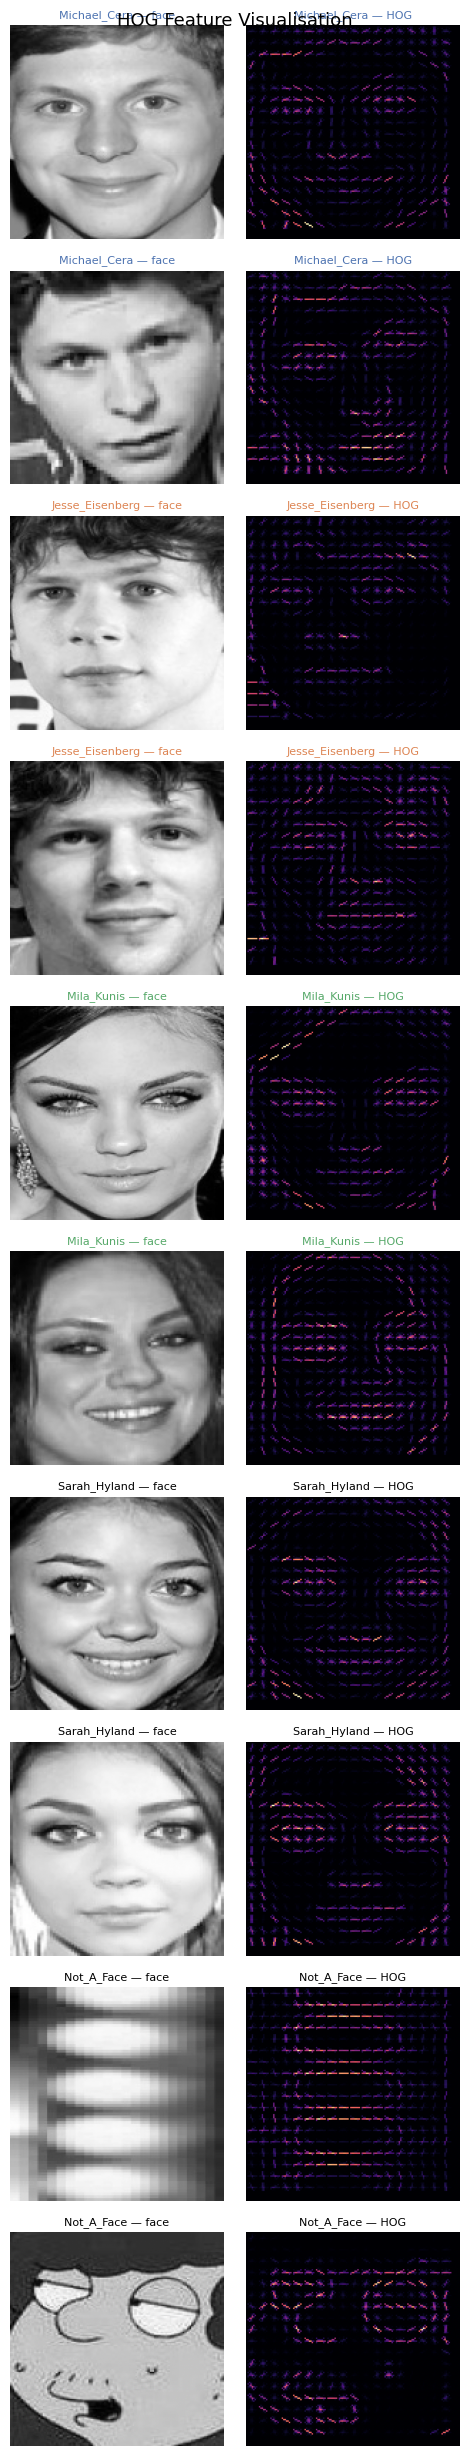

In [15]:
examples_per_person = 2

print("Visualizing HOG features...")

# Run the visualization
plot_hog_features(
    face_array=X_train_final,
    label_array=y_train_final,
    n_per_class=examples_per_person,
    class_names=CLASS_NAMES
)

### 1.1.2 t-SNE plot

t-SNE projects the 1764-dimensional HOG vectors to 2D so we can visually assess
whether the features are **discriminative** (classes form separate clusters) and
**robust** (same class forms a tight cluster despite image variation).

We use `perplexity=10` because with only 80 training samples the default of 30 is
too large — it would force every point to be considered a neighbour of every other.


In [16]:
from sklearn.manifold import TSNE

In [17]:
def plot_tsne(
    features: np.ndarray,
    label_array: np.ndarray,
    title: str = "t-SNE Feature Space",
    class_names: dict = None,
    perplexity: int = 10,
    random_state: int = 42,
) -> None:
    """
    2-D t-SNE scatter plot of *features* coloured by class with high-contrast distinct colors.
    """
    # Ensure class_names is a dictionary
    if isinstance(class_names, list):
        class_names = {i: name for i, name in enumerate(class_names)}
    elif class_names is None:
        class_names = {}

    print(f"Running t-SNE (perplexity={perplexity}) on {features.shape} ...")
    tsne = TSNE(
        n_components=2, perplexity=perplexity, random_state=random_state, max_iter=1000
    )
    coords = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(10, 8))
    classes = sorted(np.unique(label_array))

    # Define a custom, highly distinct color palette for up to 10 classes
    # We use a specific dark gray for the "Not_A_Face" class (usually class 4)
    distinct_colors = {
        0: "#1f77b4",  # Blue (Michael)
        1: "#ff7f0e",  # Orange (Jesse)
        2: "#2ca02c",  # Green (Mila)
        3: "#d62728",  # Red (Sarah)
        4: "#7f7f7f",  # Gray (Not_A_Face - makes it recede as background noise)
        5: "#9467bd",  # Purple
        6: "#8c564b",  # Brown
        7: "#e377c2",  # Pink
    }

    for i, cls in enumerate(classes):
        mask = label_array == cls

        # Grab the color from our distinct dictionary, or fall back to a random hex if we exceed 8 classes
        colour = distinct_colors.get(cls, f"#{np.random.randint(0, 0xFFFFFF):06x}")

        # Determine the label name
        label_name = class_names.get(cls, f"Class {cls}")

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=colour,
            label=label_name,
            s=80,  # Made the dots slightly larger for better visibility
            alpha=0.85,
            edgecolors="white",
            linewidths=0.5,
        )

    # Move legend outside the plot so it doesn't cover up data points
    ax.legend(fontsize=10, framealpha=1.0, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("t-SNE dim 1", fontsize=11)
    ax.set_ylabel("t-SNE dim 2", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

Running t-SNE (perplexity=10) on (102, 5292) ...


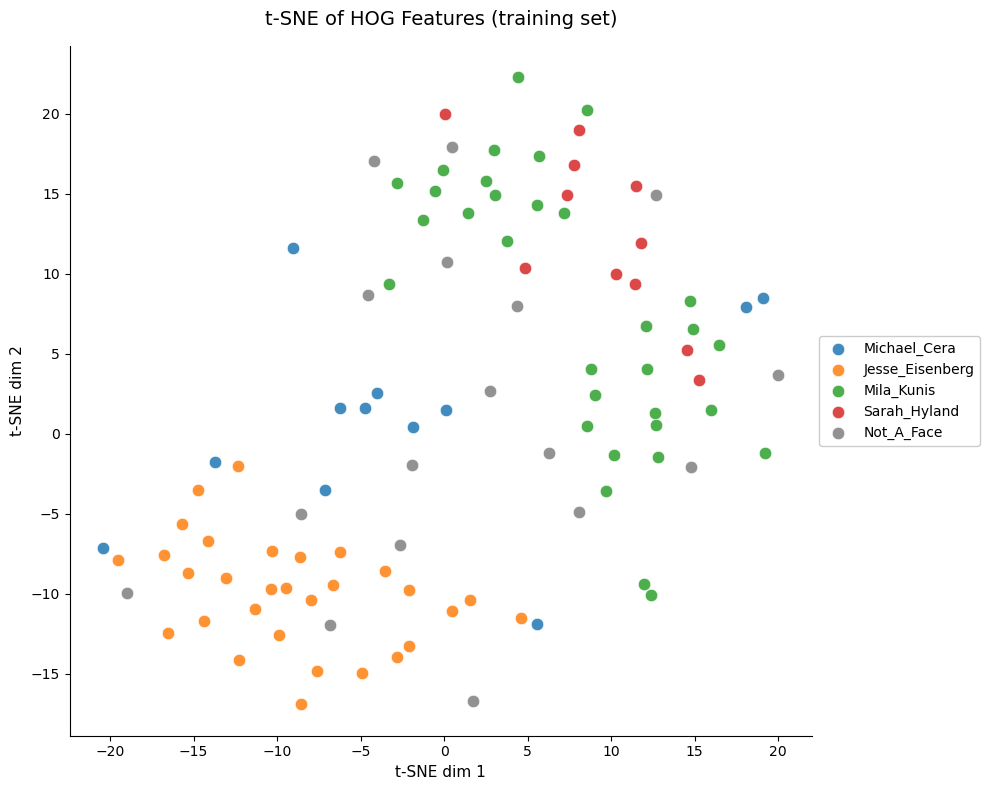

In [18]:
# t-SNE — assesses discriminability of HOG features
# Well-separated clusters = HOG captures class-specific facial structure
plot_tsne(
    features    = train_hog_features,
    label_array = y_train_final,
    title       = "t-SNE of HOG Features (training set)",
    class_names = CLASS_NAMES,
    perplexity  = 10,
)

### 1.1.3 Discussion
*[Complete after running the t-SNE — describe whether clusters are well separated,
whether Jesse and Michael overlap, and how that relates to their visual similarity.]*


## 1.2 Features learned from data: PCA / Eigenfaces

*[To be completed — see preprocessing.py for apply_pca and visualize.py for
plot_eigenfaces, plot_pca_reconstruction, plot_explained_variance, plot_pca_scatter.]*


In [19]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean_face = X.mean(axis=0)
        X_centered = X - self.mean_face
        U, self.S, self.Vt = np.linalg.svd(X_centered, full_matrices=False)

    def transform(self, X):
        return (X - self.mean_face) @ self.Vt[:self.n_components, :].T

    def inverse_transform(self, X_projected):
        return X_projected @ self.Vt[:self.n_components, :] + self.mean_face

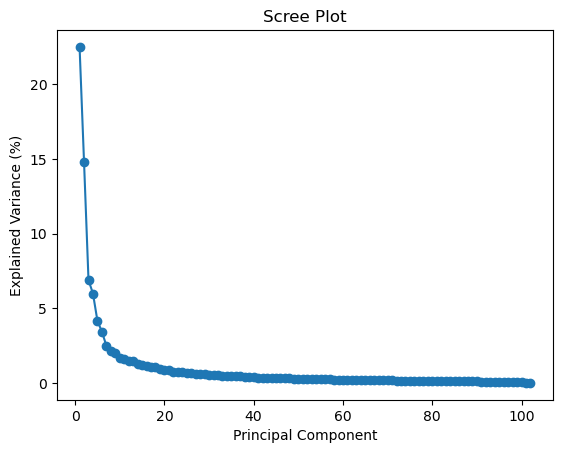

First 20 PCs explain: 78.08%


In [20]:
pca_ext = PCAFeatureExtractor(n_components=20)
pca_ext.fit(train_X_flat)

squared_s = pca_ext.S ** 2
explained_var = squared_s / squared_s.sum() * 100

plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.show()

print(f"First 20 PCs explain: {np.sum(explained_var[:20]):.2f}%")

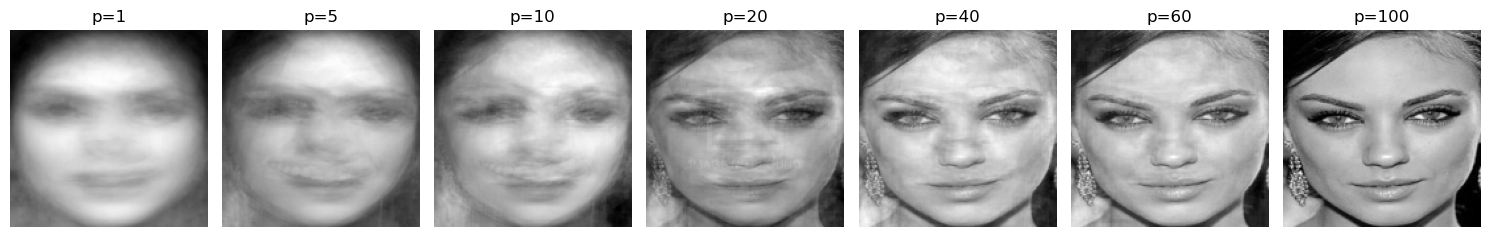

In [21]:
p = [1, 5, 10, 20, 40, 60, 100]
fig, axes = plt.subplots(1, len(p), figsize=(15, 4))
for i, p_val in enumerate(p):
    if p_val > len(train_X_flat):
        print(f"Skipping p={p_val} because you only have {len(train_X_flat)} images.")
        continue
        
    pca_temp = PCAFeatureExtractor(n_components=p_val)
    pca_temp.fit(train_X_flat)
    coefficients = pca_temp.transform(train_X_flat[0:1])
    reconstruction = pca_temp.inverse_transform(coefficients)
    
    # FIX: Reshape to 150x150
    axes[i].imshow(reconstruction.reshape(150, 150), cmap='gray')
    axes[i].set_title(f'p={p_val}')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

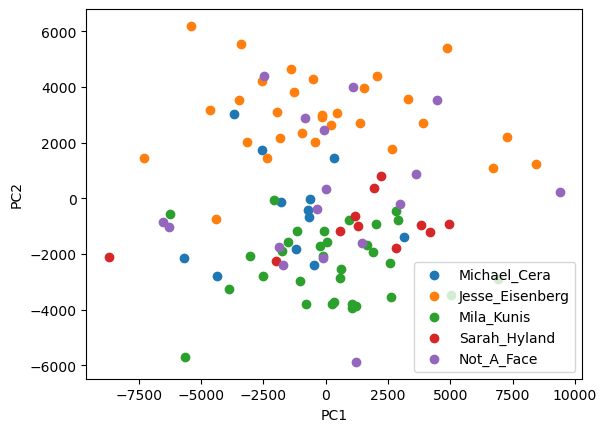

In [22]:
pca_ext = PCAFeatureExtractor(n_components=20)
pca_ext.fit(train_X_flat)
scatter = pca_ext.transform(train_X_flat)

classes = np.unique(y_train_final)
for cls, name in zip(classes, CLASS_NAMES.values()):
    mask = y_train_final == cls
    plt.scatter(scatter[mask, 0], scatter[mask, 1], label=name)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

---
# 2. Evaluation Metrics

We use **accuracy** as the primary metric because the test set class distribution
is unknown and accuracy is the Kaggle competition metric.

However, accuracy alone is insufficient with class imbalance (Jesse/Mila 30 each,
lookalikes 20 total).  We additionally report per-class **precision, recall, and F1**
via `classification_report` to detect whether the classifier ignores the minority class.


In [23]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

---
# 3. Classifiers

## 3.0 Baseline: random classifier

Randomly samples labels according to the training class distribution.
Expected accuracy ≈ 1/3 (uniform prior over 3 classes).
This sets the performance floor — any real classifier must beat this.


In [24]:
class RandomClassificationModel:
    """
    Baseline classifier — samples labels from the training class distribution.
    Expected accuracy ≈ 25% (uniform prior, 4 classes in raw data).
    Any real classifier must clearly beat this.
    """

    def fit(self, X, y):
        self.classes_, counts = np.unique(y, return_counts=True)
        self.class_ratio_     = counts / counts.sum()
        return self

    def predict(self, X):
        np.random.seed(0)
        return np.random.choice(self.classes_, size=len(X), p=self.class_ratio_)

    def __call__(self, X): return self.predict(X)


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

---
# 4. Experiments

## 4.0 Baseline: random classifier on raw DNN crops


In [26]:
feature_extractor = IdentityFeatureExtractor()
baseline_clf      = RandomClassificationModel()
baseline_clf.fit(feature_extractor(train_X_new_final), train_y_new_final)

baseline_pred = baseline_clf(feature_extractor(train_X_new_final))
print(f"Random classifier training accuracy: {accuracy_score(train_y_new_final, baseline_pred):.2f}")
print("(Expected ~0.25 — this is the performance floor)")

# Store test predictions from baseline for submission comparison
test_y_baseline = baseline_clf(feature_extractor(test_X))

NameError: name 'train_X_new_final' is not defined

In [27]:
X_train_hog = train_hog_features  
X_train_pca = pca_ext.transform(train_X_flat)
y_train = y_train_final

# 1. Define the classifiers and their hyperparameter grids
classifiers = {
    "SVM_Linear": {
        "model": SVC(kernel='linear', random_state=42),
        "params": {
            "classifier__C": [0.1, 1, 10]
        }
    },
    "SVM_RBF": {
        "model": SVC(kernel='rbf', random_state=42),
        "params": {
            "classifier__C": [0.1, 1, 10, 100],
            "classifier__gamma": ['scale', 'auto', 0.01, 0.1]
        }
    },
    "SVM_Poly": {
        "model": SVC(kernel='poly', random_state=42),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__degree": [2, 3, 4]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(eval_metric='mlogloss', random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100, 200],
            "classifier__max_depth": [3, 5, 7],
        }
    },
    "Logistic_Regression": {
        "model": LogisticRegression(max_iter=2000, random_state=42),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10, 100],
        }
    },
    "Ridge_Classifier": {
        "model": RidgeClassifier(random_state=42),
        "params": {
            "classifier__alpha": [0.1, 1.0, 10.0, 100.0]
        }
    },
    "Random_Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100, 200],
            "classifier__max_depth": [None, 5, 10]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "classifier__n_neighbors": [3, 5, 7],
            "classifier__weights": ['uniform', 'distance']
        }
    }
}

In [28]:
X_train_hog.shape

(102, 5292)

In [29]:
X_train_pca.shape

(102, 20)

In [30]:
y_train.shape

(102,)

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [34]:
best_hog_models = {}
hog_results = []


print("==== Starting Grid Search with Cross-Validation for HOG Features ====\n")
# 3. Loop through the dictionary, build the pipeline, and perform Grid Search
for clf_name, clf_info in classifiers.items():
    print(f"Training and Tuning {clf_name}...")
    
    # Build pipeline: StandardScaler -> Classifier
    pipeline = Pipeline([
        ('classifier', clf_info["model"])
    ])
    
    # Setup GridSearchCV
    hog_grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=clf_info["params"],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the model using cross-validation
    hog_grid_search.fit(X_train_hog, y_train_final)
    
    # Store the best model and append results
    best_hog_models[clf_name] = hog_grid_search.best_estimator_
    
    hog_results.append({
        "Classifier": clf_name,
        "Best Parameters": hog_grid_search.best_params_,
        "Best CV Accuracy": hog_grid_search.best_score_
    })
    print(f"Best CV Accuracy for {clf_name}: {hog_grid_search.best_score_:.4f}\n")

# 4. Display Summary of Results
hog_results_df = pd.DataFrame(hog_results).sort_values(by="Best CV Accuracy", ascending=False)
print("=== Cross-Validation Results ===")
print(hog_results_df.to_string(index=False))

overall_best__hog_name = hog_results_df.iloc[0]["Classifier"]
best_hog_pipeline = best_hog_models[overall_best__hog_name]

==== Starting Grid Search with Cross-Validation for HOG Features ====

Training and Tuning SVM_Linear...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best CV Accuracy for SVM_Linear: 0.7157

Training and Tuning SVM_RBF...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV Accuracy for SVM_RBF: 0.7243

Training and Tuning SVM_Poly...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV Accuracy for SVM_Poly: 0.7243

Training and Tuning XGBoost...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV Accuracy for XGBoost: 0.6662

Training and Tuning Logistic_Regression...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV Accuracy for Logistic_Regression: 0.7538

Training and Tuning Ridge_Classifier...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best CV Accuracy for Ridge_Classifier: 0.7548

Training and Tuning Random_Forest...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV

In [35]:
best_pca_models = {}
pca_results = []


print("==== Starting Grid Search with Cross-Validation for PCA Features ====\n")
# 3. Loop through the dictionary, build the pipeline, and perform Grid Search
for clf_name, clf_info in classifiers.items():
    print(f"Training and Tuning {clf_name}...")
    
    # Build pipeline: StandardScaler -> Classifier
    pipeline = Pipeline([
        ('classifier', clf_info["model"])
    ])
    
    # Setup GridSearchCV
    pca_grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=clf_info["params"],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the model using cross-validation
    pca_grid_search.fit(X_train_pca, y_train_final)
    
    # Store the best model and append results
    best_pca_models[clf_name] = pca_grid_search.best_estimator_
    
    pca_results.append({
        "Classifier": clf_name,
        "Best Parameters": pca_grid_search.best_params_,
        "Best CV Accuracy": pca_grid_search.best_score_
    })
    print(f"Best CV Accuracy for {clf_name}: {pca_grid_search.best_score_:.4f}\n")

# 4. Display Summary of Results
pca_results_df = pd.DataFrame(pca_results).sort_values(by="Best CV Accuracy", ascending=False)
print("=== Cross-Validation Results ===")
print(pca_results_df.to_string(index=False))

==== Starting Grid Search with Cross-Validation for PCA Features ====

Training and Tuning SVM_Linear...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best CV Accuracy for SVM_Linear: 0.5386

Training and Tuning SVM_RBF...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV Accuracy for SVM_RBF: 0.6576

Training and Tuning SVM_Poly...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV Accuracy for SVM_Poly: 0.6171

Training and Tuning XGBoost...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV Accuracy for XGBoost: 0.6586

Training and Tuning Logistic_Regression...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV Accuracy for Logistic_Regression: 0.5300

Training and Tuning Ridge_Classifier...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best CV Accuracy for Ridge_Classifier: 0.6276

Training and Tuning Random_Forest...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV

In [42]:
hog_best_model = hog_grid_search.best_estimator_
hog_best_params = hog_grid_search.best_params_
hog_best_score = hog_grid_search.best_score_

print(f"Best HOG Classifier: {hog_best_model}")
print(f"Best Parameters: {hog_best_params}")
print(f"Best Cross-Val Score: {hog_best_score:.4f}")

final_hog_classifier = XGBClassifier(**hog_best_params)

final_hog_classifier.fit(X_train_hog, y_train_final)

Best HOG Classifier: Pipeline(steps=[('classifier', KNeighborsClassifier(n_neighbors=3))])
Best Parameters: {'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
Best Cross-Val Score: 0.7352


/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [00:03:56] WARNING: /home/task_177465307475651/croot/xgboost-split_1774653124670/work/src/learner.cc:782: 
Parameters: { "classifier__n_neighbors", "classifier__weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [44]:
pca_best_model = pca_grid_search.best_estimator_
pca_best_params = pca_grid_search.best_params_
pca_best_score = pca_grid_search.best_score_

print(f"Best PCA Classifier: {pca_best_model}")
print(f"Best Parameters: {pca_best_params}")
print(f"Best Cross-Val Score: {pca_best_score:.4f}")

final_pca_classifier = XGBClassifier(**pca_best_params)

final_pca_classifier.fit(X_train_pca, y_train_final)

Best PCA Classifier: Pipeline(steps=[('classifier',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])
Best Parameters: {'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
Best Cross-Val Score: 0.6281


/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [00:04:36] WARNING: /home/task_177465307475651/croot/xgboost-split_1774653124670/work/src/learner.cc:782: 
Parameters: { "classifier__n_neighbors", "classifier__weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [45]:
overall_best__hog_name = hog_results_df.iloc[0]["Classifier"]
best_hog_pipeline = best_hog_models[overall_best__hog_name]

overall_best_pca_name = pca_results_df.iloc[0]["Classifier"]
best_pca_pipeline = best_pca_models[overall_best_pca_name]

### Test predictions

In [ ]:
def predict_test_image(img, best_pipeline, feature_extractor_func, face_detector, target_size=(150, 150)):
    """
    Reads an image, extracts all faces using DNNFaceDetector, passes them 
    through the pipeline, and applies priority logic: Mila (2) > Jesse (1) > Other (0).
    If no face is found, it immediately returns 0.
    """
    
    # 1. Ensure image is loaded and in RGB format 
    if isinstance(img, str):
        img_bgr = cv2.imread(img)
        if img_bgr is None:
            print(f"Warning: Could not load image at {img}")
            return 0 
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        # Assuming if an array is passed, it's already RGB
        img_rgb = img 
        
    # 2. Extract faces using your custom DNN Face Detector
    faces = face_detector.detect_faces(img_rgb)
    
    # *** IMMEDIATE FALLBACK TO 'OTHER' IF NO FACES FOUND ***
    if not faces:
        return 0 
        
    predictions = []
    
    # 3. Process each face found
    for (x, y, w, h, conf, sharp) in faces:
        
        face_crop = img_rgb[y:y+h, x:x+w]
        face_resized = cv2.resize(face_crop, target_size)
        
        # Extract features (your HOG extractor expects the 3-channel RGB image here)
        features = feature_extractor_func(face_resized)
        
        # Reshape to 2D array (1, n_features) as required by scikit-learn
        features_2d = np.array(features).reshape(1, -1)
        
        # Predict 
        pred = best_pipeline.predict(features_2d)[0]
        predictions.append(pred)
        
    # 4. Final Output Logic
    if 2 in predictions:      # 2 is Mila
        return 2
    elif 1 in predictions:    # 1 is Jesse
        return 1
    else:
        return 0              # 0 is Michael/Sarah/Other

In [48]:
face_detector = DNNFaceDetector(path="models", face_size=TARGET_SIZE)

In [49]:
from tqdm import tqdm

# Create an empty list to store your final answers (if you haven't already)
final_test_predictions = []

# Loop through your test dataset with tqdm
for index, row in tqdm(test.iterrows(), total=len(test), desc="Classifying Test Images"):
    raw_image = row['img'] # Assuming your raw images are in the 'img' column
    
    # Run your custom function
    final_label = predict_test_image(
        img=raw_image, 
        best_pipeline=best_hog_pipeline, 
        feature_extractor_func=hog_ext, 
        face_detector=face_detector, 
        target_size=(150, 150) # Make sure this matches the 150x150 we used earlier!
    )
    
    final_test_predictions.append(final_label)

print("Done! Here is a preview:")

Classifying Test Images: 100%|██████████| 1816/1816 [09:22<00:00,  3.23it/s]

Done! Here is a preview:


In [ ]:
# 1. Load the labels back from your saved file
if final_test_predictions:
    labels = np.array(final_test_predictions)
else:
    submission_df = pd.read_csv('submission.csv')
    labels = submission_df['class'].values

# 2. Setup the plotting grid (10x10)
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten() # Flatten so we can iterate with a single index

for i in range(100):
    # Display the image from your 'test' dataframe
    # Assuming 'img' column contains the pixel arrays
    axes[i].imshow(test.iloc[i]['img'])
    
    # Set the title using the 'class' we just extracted
    axes[i].set_title(f"Pred: {labels[i]}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
# 5. Publishing Best Results

Update `submission['class']` below with the predictions from your best model
before saving.  Current default: HOG + RBF SVM predictions.


In [92]:
best_predictions = final_test_predictions

submission = test.copy().drop('img', axis=1)
submission = submission.drop('predictions', axis=1)
submission['class'] = best_predictions
submission.to_csv('submission.csv')

print(f"Saved {len(submission)} predictions to submission.csv")
submission.head()


Saved 1816 predictions to submission.csv


,class
id,
0,1
1,0
2,0
3,0
4,1


---
# 6. Discussion

*[To be completed after all experiments are done.]*

### Summary of findings

| Pipeline | Val accuracy | Notes |
|----------|-------------|-------|
| Random baseline | ~25% | Performance floor |
| HOG + RBF SVM | TBD | |
| PCA + classifier | TBD | |

### Feature representation comparison

*Discuss: which features are more discriminative/robust and why?
When does HOG fail? When does PCA fail?*

### Limitations and future work

- ~5% of Jesse training images contain Michael Cera as the dominant face.
  A face recognition model (e.g. FaceNet) could resolve this by identifying
  the person rather than selecting by geometric prominence.
- With only 80 training samples, any model risks overfitting.
  Data augmentation (flipping, brightness jitter) could improve generalisation.


In [52]:
from facenet_pytorch import InceptionResnetV1
from torchvision import transforms
import torch

In [53]:
resnet = InceptionResnetV1(pretrained='vggface2').eval()

# Move to GPU if available for faster extraction
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet = resnet.to(device)

In [54]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [56]:
def extract_facenet_features_batch(faces_array):
    """
    Takes a numpy array of faces of shape (N, H, W, 3) in BGR format, 
    and returns an (N, 512) array of FaceNet embeddings.
    """
    processed_tensors = []
    
    # 1. Loop through the array to apply OpenCV and preprocessing steps to each image
    for face_crop_bgr in faces_array:
        # Convert BGR to RGB
        face_rgb = cv2.cvtColor(face_crop_bgr, cv2.COLOR_BGR2RGB)
        
        # Resize to 160x160
        face_resized = cv2.resize(face_rgb, (160, 160))
        
        # Preprocess to tensor and normalize (Shape: 3, 160, 160)
        face_tensor = preprocess(face_resized)
        processed_tensors.append(face_tensor)
        
    # 2. Stack all individual tensors into a single batch tensor
    # Shape becomes (N, 3, 160, 160)
    batch_tensor = torch.stack(processed_tensors).to(device)
    
    # 3. Pass the entire batch through the model at once
    with torch.no_grad():
        embeddings = resnet(batch_tensor)
        
    # 4. Move back to CPU and convert to numpy. 
    # We do NOT flatten here, so the output retains the shape (N, 512)
    return embeddings.cpu().numpy()

In [57]:
all_embeddings = extract_facenet_features_batch(X_train_final)

In [87]:
clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
clf.fit(all_embeddings, y_train_final)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [88]:
def predict_test_images(images, model, feature_extractor_func, face_detector):
    """
    Takes a list of images (either file paths or BGR numpy arrays), 
    extracts faces from each, batches ALL faces for feature extraction 
    and prediction, and returns a list of final predictions.
    Priority logic: Mila (2) > Jesse (1) > Other (0).
    """
    all_face_crops = []
    face_to_img_idx = [] # Keeps track of which image each face belongs to
    
    # 1. Detect faces in each image and collect the crops
    for i, img in enumerate(images):
        # If the input is a file path, load it to get the "actual image" for the detector
        if isinstance(img, str):
            img_bgr = cv2.imread(img)
            if img_bgr is None:
                print(f"Warning: Could not load image at {img}")
                continue
        else:
            img_bgr = img # Assuming it's already a loaded BGR numpy array
            
        # Detect faces on the actual image
        faces = face_detector.detect_faces(img_bgr)
        
        # If faces are found, crop them and record their source image index
        if faces:
            for (x, y, w, h, conf, sharp) in faces:
                face_crop = img_bgr[y:y+h, x:x+w]
                all_face_crops.append(face_crop)
                face_to_img_idx.append(i)
                
    # *** IMMEDIATE FALLBACK IF NO FACES FOUND IN ANY IMAGE ***
    if not all_face_crops:
        return [0] * len(images)
        
    # 2. Batch Feature Extraction
    # Pass the entire list of BGR crops from ALL images at once.
    # Returns shape (Total_Faces, 512)
    embeddings = feature_extractor_func(all_face_crops)
    
    # 3. Batch Prediction
    # Pass the embeddings directly to the model.
    # Returns shape (Total_Faces,)
    predictions = model.predict(embeddings)
    
    # 4. Map predictions back to their original images and apply priority logic
    final_results = [0] * len(images) # Default everyone to 0 (Other/No Face)
    
    # Group predictions by the image they came from
    preds_per_image = {}
    for img_idx, pred in zip(face_to_img_idx, predictions):
        if img_idx not in preds_per_image:
            preds_per_image[img_idx] = []
        preds_per_image[img_idx].append(pred)
        
    # 5. Apply Output Logic (Priority: 2 > 1 > 0) per image
    for i in range(len(images)):
        if i in preds_per_image:
            img_preds = preds_per_image[i]
            if 2 in img_preds:      # 2 is Mila
                final_results[i] = 2
            elif 1 in img_preds:    # 1 is Jesse
                final_results[i] = 1
            else:
                final_results[i] = 0  # 0 is Other
                
    return final_results

In [89]:
# 1. Extract all raw images from the dataframe into a Python list
all_raw_images = test['img'].tolist()

final_test_predictions = []

# Set a batch size (adjust this based on your GPU/CPU memory)
# 32 or 64 is usually a safe starting point.
batch_size = 32 

# 2. Loop through the list in chunks
for i in tqdm(range(0, len(all_raw_images), batch_size), desc="Classifying Test Batches"):
    
    # Slice the list to get the current batch of images
    batch_images = all_raw_images[i:i + batch_size]
    
    # Run our new batch function on this chunk
    batch_labels = predict_test_images(
        images=batch_images, 
        model=clf, # Make sure to pass your actual trained model here
        feature_extractor_func=extract_facenet_features_batch, 
        face_detector=face_detector
    )
    
    # Extend the final list with the results from this batch
    final_test_predictions.extend(batch_labels)

# Optional: Attach the predictions directly back to your dataframe for easy viewing
test['predictions'] = final_test_predictions

print("Done! Here is a preview:")
print(test.head())

Classifying Test Batches: 100%|██████████| 57/57 [04:50<00:00,  5.09s/it]


Done! Here is a preview:
                                                  img  predictions
id                                                                
0   [[[209, 210, 205], [208, 209, 204], [208, 209,...            1
1   [[[146, 113, 36], [147, 114, 37], [147, 114, 3...            0
2   [[[194, 192, 193], [194, 192, 193], [193, 193,...            0
3   [[[121, 121, 121], [121, 121, 121], [121, 121,...            0
4   [[[228, 228, 230], [228, 228, 230], [228, 228,...            1


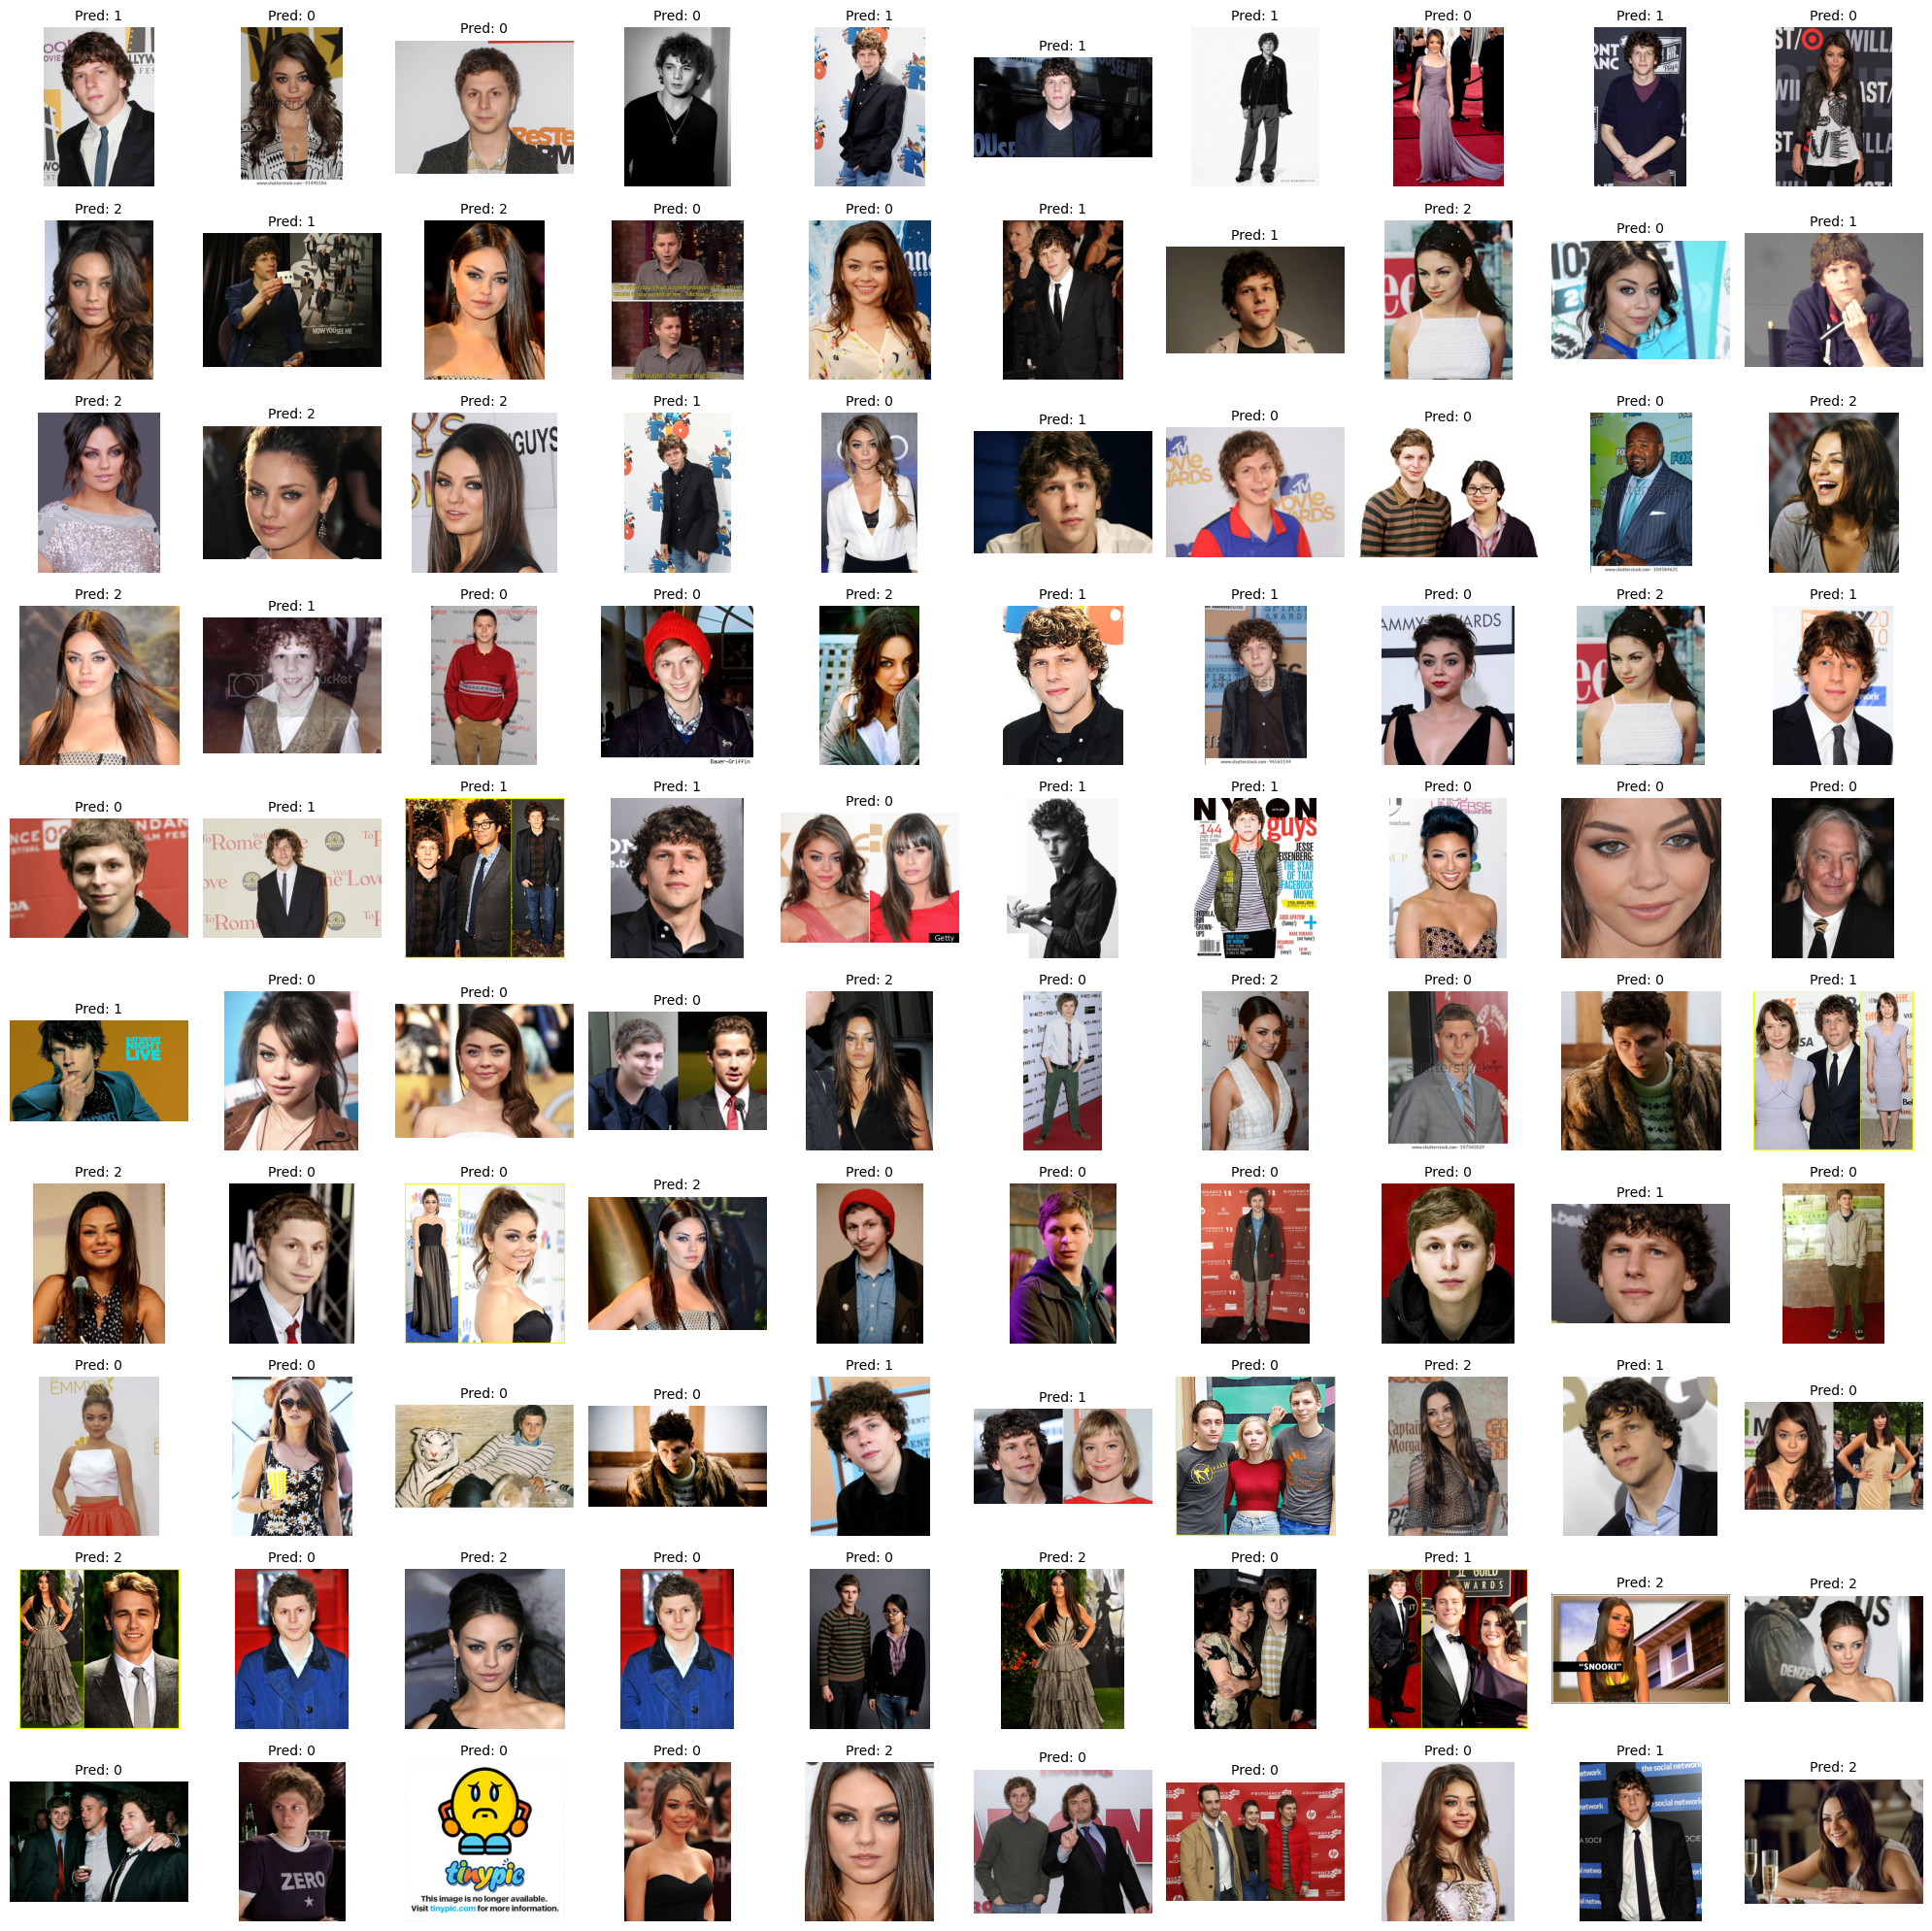

In [90]:
# 1. Load the labels back from your saved file
if final_test_predictions:
    labels = np.array(final_test_predictions)
else:
    submission_df = pd.read_csv('submission.csv')
    labels = submission_df['class'].values

# 2. Setup the plotting grid (10x10)
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten() # Flatten so we can iterate with a single index

for i in range(100):
    # Display the image from your 'test' dataframe
    # Assuming 'img' column contains the pixel arrays
    axes[i].imshow(test.iloc[i]['img'])
    
    # Set the title using the 'class' we just extracted
    axes[i].set_title(f"Pred: {labels[i]}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()